# From 8 minutes to 4 seconds
## Solving large systems with Jacobi + GMRES

**Romain Sacchi (PSI) · Brightcon 2026 · 25 September 2026 · 10 minutes**  
Open Tools and Development · Aalborg University & Online

> A direct sparse factorisation is robust, but fill-in can dominate memory and runtime. A Jacobi-preconditioned GMRES solve trades exactness for a controlled residual—and can make much larger LCA systems tractable.

[Conference contribution](https://indico.d-d-s.ch/event/2/contributions/59/) · Requires `bw2calc>=2.4.0` for the Brightway API demo.


## The 10-minute route

1. **The bottleneck** — sparse does not guarantee a cheap factorisation.
2. **The alternative** — GMRES plus an inexpensive diagonal (Jacobi) preconditioner.
3. **The evidence** — two reported large-system timings and one reproducible accuracy check.
4. **The API** — switch from `LCA` to `JacobiGMRESLCA`.
5. **The trade-off** — monitor convergence; approximate deliberately.

Audience: Brightway users and developers who know what a technosphere matrix is. No local Brightway database is needed until the final optional example.


In [1]:
from __future__ import annotations

from importlib import metadata
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
from scipy import sparse
from scipy.sparse.linalg import LinearOperator, gmres, spsolve

SEED = 2026

def find_repo_root(start: Path = Path.cwd()) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'data' / 'reported_benchmarks.csv').exists():
            return candidate
    raise FileNotFoundError('Run this notebook from inside the repository.')

ROOT = find_repo_root()
{
    'numpy': np.__version__,
    'scipy': scipy.__version__,
    'pandas': pd.__version__,
}


{'numpy': '1.24.4', 'scipy': '1.15.2', 'pandas': '2.2.3'}

## 1 · Why change the solver?

Brightway solves the inventory equation $Ax=b$, where $A$ is the technosphere matrix and $b$ is the demand. Direct sparse methods factorise $A$ and are an excellent default—but factorisation can create substantial **fill-in**, consuming far more memory than the original sparse matrix.

The following values are **approximate timings reported in the conference abstract**. They are not controlled measurements reproduced in this repository; the source does not state the hardware or all solver settings.


In [2]:
reported = pd.read_csv(ROOT / 'data' / 'reported_benchmarks.csv')
assert reported['status'].eq('reported').all()
assert (reported[['direct_seconds', 'jacobi_gmres_seconds']] > 0).all().all()

reported_view = reported.assign(
    speedup=lambda frame: frame.direct_seconds / frame.jacobi_gmres_seconds,
)[['system', 'dimension_rows', 'density', 'direct_seconds', 'jacobi_gmres_seconds', 'speedup']]

reported_view.style.format({
    'dimension_rows': '{:,.0f}',
    'density': lambda value: 'not reported' if pd.isna(value) else f'{value:.3%}',
    'direct_seconds': '{:,.2f}',
    'jacobi_gmres_seconds': '{:,.2f}',
    'speedup': '{:,.0f}×',
})


,system,dimension_rows,density,direct_seconds,jacobi_gmres_seconds,speedup
0,Regionalised technosphere system,"250,000",not reported,480.00,4.00,120×
1,Synthetic technosphere-like system,"40,000",0.100%,"1,540.00",0.02,"77,000×"


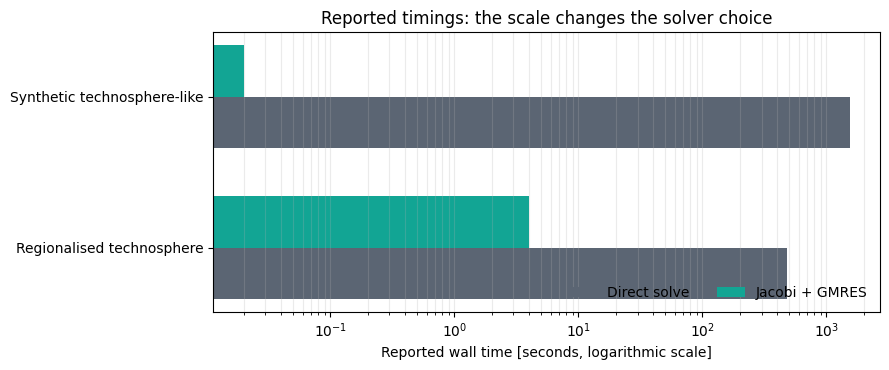

In [3]:
labels = reported['system'].str.replace(' system', '', regex=False)
positions = np.arange(len(reported))
height = 0.34

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.barh(positions - height / 2, reported.direct_seconds, height, label='Direct solve', color='#5B6573')
ax.barh(positions + height / 2, reported.jacobi_gmres_seconds, height, label='Jacobi + GMRES', color='#12A594')
ax.set_xscale('log')
ax.set_yticks(positions, labels)
ax.set_xlabel('Reported wall time [seconds, logarithmic scale]')
ax.set_title('Reported timings: the scale changes the solver choice')
ax.grid(axis='x', which='both', alpha=0.25)
ax.legend(frameon=False, ncol=2, loc='lower right')
fig.tight_layout()
plt.show()


## 2 · What Jacobi + GMRES changes

GMRES builds an approximate solution in a Krylov subspace instead of explicitly factorising the full matrix. The Jacobi preconditioner uses only the inverse diagonal, $M^{-1}=D^{-1}$, to improve the system seen by GMRES.

- **Cheap setup:** one diagonal extraction and reciprocal.
- **Controlled approximation:** stop when the residual satisfies the requested tolerance.
- **Lower memory pressure:** avoid a potentially expensive direct factorisation.
- **No universal win:** convergence depends on matrix structure; direct solving remains the safer default for small or difficult systems.

The next example is intentionally small. It demonstrates correctness and diagnostics, not the large-system timing claim.


In [4]:
def make_technosphere_like(
    n: int = 4_000, density: float = 5e-4, seed: int = SEED
) -> tuple[sparse.csr_matrix, np.ndarray]:
    """Create a diagonally dominant, sparse demonstration system."""
    rng = np.random.default_rng(seed)
    off_diagonal = sparse.random(
        n,
        n,
        density=density,
        format='csr',
        random_state=rng,
        data_rvs=lambda size: rng.uniform(0.0, 0.02, size),
    )
    off_diagonal.setdiag(0.0)
    off_diagonal.eliminate_zeros()
    # A weak chain guarantees that a one-process demand propagates upstream.
    chain = sparse.diags(np.full(n - 1, 0.15), offsets=-1, format='csr')
    matrix = sparse.eye(n, format='csr') - off_diagonal - chain
    demand = np.zeros(n)
    demand[0] = 1.0
    return matrix, demand

A, b = make_technosphere_like()
{
    'shape': A.shape,
    'nonzeros': A.nnz,
    'density': A.nnz / np.prod(A.shape),
    'sparse_storage_MiB': (A.data.nbytes + A.indices.nbytes + A.indptr.nbytes) / 2**20,
}


{'shape': (4000, 4000),
 'nonzeros': 15993,
 'density': 0.0009995625,
 'sparse_storage_MiB': 0.1982879638671875}

In [5]:
def solve_with_jacobi_gmres(
    matrix: sparse.csr_matrix,
    demand: np.ndarray,
    *,
    rtol: float = 1e-8,
    restart: int = 50,
    maxiter: int = 300,
) -> tuple[np.ndarray, int, list[float]]:
    diagonal = matrix.diagonal()
    if np.any(np.isclose(diagonal, 0.0)):
        raise ValueError('A Jacobi preconditioner requires a non-zero diagonal.')

    preconditioner = LinearOperator(
        matrix.shape, matvec=lambda vector: vector / diagonal
    )
    residual_history: list[float] = []
    solution, info = gmres(
        matrix,
        demand,
        M=preconditioner,
        rtol=rtol,
        atol=0.0,
        restart=restart,
        maxiter=maxiter,
        callback=residual_history.append,
        callback_type='pr_norm',
    )
    return solution, info, residual_history

started = perf_counter()
x_direct = spsolve(A, b)
direct_seconds = perf_counter() - started

started = perf_counter()
x_iterative, info, residual_history = solve_with_jacobi_gmres(A, b)
iterative_seconds = perf_counter() - started

assert info == 0, f'GMRES did not converge; SciPy info={info}'


In [6]:
def relative_residual(matrix, solution, demand) -> float:
    return np.linalg.norm(matrix @ solution - demand) / np.linalg.norm(demand)

diagnostics = pd.Series({
    'direct time [s]': direct_seconds,
    'Jacobi + GMRES time [s]': iterative_seconds,
    'GMRES inner iterations': len(residual_history),
    'direct relative residual': relative_residual(A, x_direct, b),
    'GMRES relative residual': relative_residual(A, x_iterative, b),
    'solution relative difference': (
        np.linalg.norm(x_iterative - x_direct) / np.linalg.norm(x_direct)
    ),
})
diagnostics.to_frame('illustrative local result').style.format('{:.3e}')


,illustrative local result
direct time [s],5.700e-02
Jacobi + GMRES time [s],2.531e-03
GMRES inner iterations,1.000e+01
direct relative residual,6.753e-18
GMRES relative residual,5.972e-09
solution relative difference,6.126e-09


## 3 · Audience exercise: choose the approximation

Predict what happens as `rtol` becomes stricter: How do iteration count and the true residual change? The answer scaffold below runs the same matrix at three tolerances.


In [7]:
tolerance_results = []
for tolerance in (1e-4, 1e-6, 1e-8):
    solution, status, history = solve_with_jacobi_gmres(A, b, rtol=tolerance)
    tolerance_results.append({
        'requested rtol': tolerance,
        'converged': status == 0,
        'inner iterations': len(history),
        'measured relative residual': relative_residual(A, solution, b),
    })

pd.DataFrame(tolerance_results).style.format({
    'requested rtol': '{:.0e}',
    'measured relative residual': '{:.2e}',
})


,requested rtol,converged,inner iterations,measured relative residual
0,1e-04,True,5,7.56e-05
1,1e-06,True,8,2.60e-07
2,1e-08,True,10,5.97e-09


## 4 · The Brightway 2.5 switch

`JacobiGMRESLCA` was added in `bw2calc` 2.4.0. It accepts the usual demand, method, and datapackage inputs, plus `rtol`, `atol`, `restart`, `maxiter`, and `use_guess`. Reusing the previous solution as the next initial guess can help repeated solves.


In [8]:
try:
    installed_bw2calc = metadata.version('bw2calc')
    from bw2calc import JacobiGMRESLCA
except (metadata.PackageNotFoundError, ImportError):
    installed_bw2calc = 'missing or older than 2.4.0'
    JacobiGMRESLCA = None

{
    'installed bw2calc': installed_bw2calc,
    'JacobiGMRESLCA available': JacobiGMRESLCA is not None,
}


{'installed bw2calc': '2.4.0', 'JacobiGMRESLCA available': True}

```python
from bw2calc import JacobiGMRESLCA

lca = JacobiGMRESLCA(
    {activity: 1},
    method=method,
    rtol=1e-8,
    atol=0.0,
    restart=50,
    maxiter=300,
    use_guess=True,
)
lca.lci()
lca.lcia()
print(lca.score)
```

For a reproducible project-backed benchmark, record the exact project, database, activity key and unit, LCIA method tuple and unit, matrix metadata, tolerances, package versions, hardware, residual, wall time, and peak memory.


## 5 · Takeaways and pitfalls

1. **Factorisation is the scaling problem.** Matrix sparsity alone does not bound fill-in.
2. **Approximation is explicit.** Report convergence settings and verify the residual.
3. **Jacobi is intentionally simple.** A zero or badly scaled diagonal is a warning; convergence is matrix-dependent.
4. **Small systems may not benefit.** Solver selection should follow evidence, not fashion.
5. **At large scale, the payoff can be decisive.** The reported cases move from minutes to seconds—or fractions of a second.

> **One-line close:** `JacobiGMRESLCA` makes the accuracy–memory–runtime trade-off controllable, opening larger Brightway systems to ordinary hardware.
